# Capstone Project: Sales Data Analysis and Customer Insights

## Executive Summary
This analysis examines sales and customer data to identify key business insights, customer segments, and opportunities for revenue growth. The project demonstrates comprehensive data analysis skills including data cleaning, statistical analysis, visualization, and machine learning.

## Table of Contents
1. [Data Loading and Exploration](#1-data-loading-and-exploration)
2. [Data Cleaning and Preprocessing](#2-data-cleaning-and-preprocessing)
3. [Statistical Analysis](#3-statistical-analysis)
4. [Data Visualization](#4-data-visualization)
5. [Machine Learning Implementation](#5-machine-learning-implementation)
6. [Business Insights and Recommendations](#6-business-insights-and-recommendations)


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
print(plt.style.available)
plt.style.use('seaborn-v0_8-dark')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
# Load the dataset
file_path = "/Users/tristanpoul/Library/CloudStorage/GoogleDrive-tpoul@scu.edu/Shared drives/OMIS 114 Capstone/data/sales_data.csv"

# read CSV and parse dates up-front
df = pd.read_csv(
    file_path,
    dtype={
        "customer_id": "string",
        "gender": "string",
        "location": "string",
        "product_category": "string",
        "brand": "string",
    },
)

# convert date columns
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors="coerce")


print(f"Shape: {df.shape}")
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/tristanpoul/Library/CloudStorage/GoogleDrive-tpoul@scu.edu/Shared drives/OMIS 114 Capstone/data/sales_data.csv'

In [ ]:
# Data quality assessment
total_rows = len(df)
duplicates = df.duplicated().sum()

missing_values = df.isna().sum()
missing_pct = (missing_values / total_rows * 100).round(2)

print("=== DATA QUALITY REPORT ===")
print(f"Total rows: {total_rows}")
print(f"Total columns: {df.shape[1]}")
print(f"Duplicate rows: {duplicates}")

quality = (
    pd.DataFrame(
        {
            "Missing Values": missing_values,
            "Missing %": missing_pct,
            "Dtype": df.dtypes.astype(str),
            "Unique": df.nunique(),
        }
    )
    .sort_values("Missing %", ascending=False)
)
display(quality)


=== DATA QUALITY REPORT ===
Total rows: 10000
Total columns: 15
Duplicate rows: 0


,Missing Values,Missing %,Dtype,Unique
age,792,7.92,float64,59
income,557,5.57,float64,7753
gender,524,5.24,string,3
location,408,4.08,string,20
customer_id,0,0.00,string,10000
registration_date,0,0.00,datetime64[ns],1065
purchase_date,0,0.00,datetime64[ns],997
product_category,0,0.00,string,8
brand,0,0.00,string,8
price,0,0.00,float64,7436


=== NUMERICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
age,9208.0,34.999457,11.247799,18.00,26.0000,34.000,43.0000,80.00
income,9443.0,41552.713227,21242.242574,20000.00,25805.0000,36226.000,51015.0000,200000.00
price,10000.0,83.449452,67.243974,10.00,32.2475,61.020,118.1975,395.40
quantity,10000.0,3.007700,1.420508,1.00,2.0000,3.000,4.0000,11.00
revenue,10000.0,249.741729,249.824137,10.00,79.4275,165.060,336.2650,2374.86
purchase_frequency,10000.0,3.993100,1.734345,1.00,3.0000,4.000,5.0000,11.00
avg_order_value,10000.0,249.385752,252.387592,8.03,77.5875,162.075,333.0175,2820.15
customer_lifespan,10000.0,1.536834,0.843773,0.08,0.8000,1.530,2.2800,3.00



=== CATEGORICAL SUMMARY (top 5) ===

customer_id:


,count
customer_id,
CUST_00001,1
CUST_00009,1
CUST_00018,1
CUST_00003,1
CUST_00004,1



gender:


...

,count
location,
Jacksonville,539
Indianapolis,516
Seattle,504
Dallas,500
Fort Worth,498



product_category:


,count
product_category,
Automotive,1331
Sports,1299
Clothing,1273
Beauty,1267
Books,1251



brand:


,count
brand,
Brand E,1274
Brand C,1262
Brand B,1254
Brand D,1251
Brand H,1247


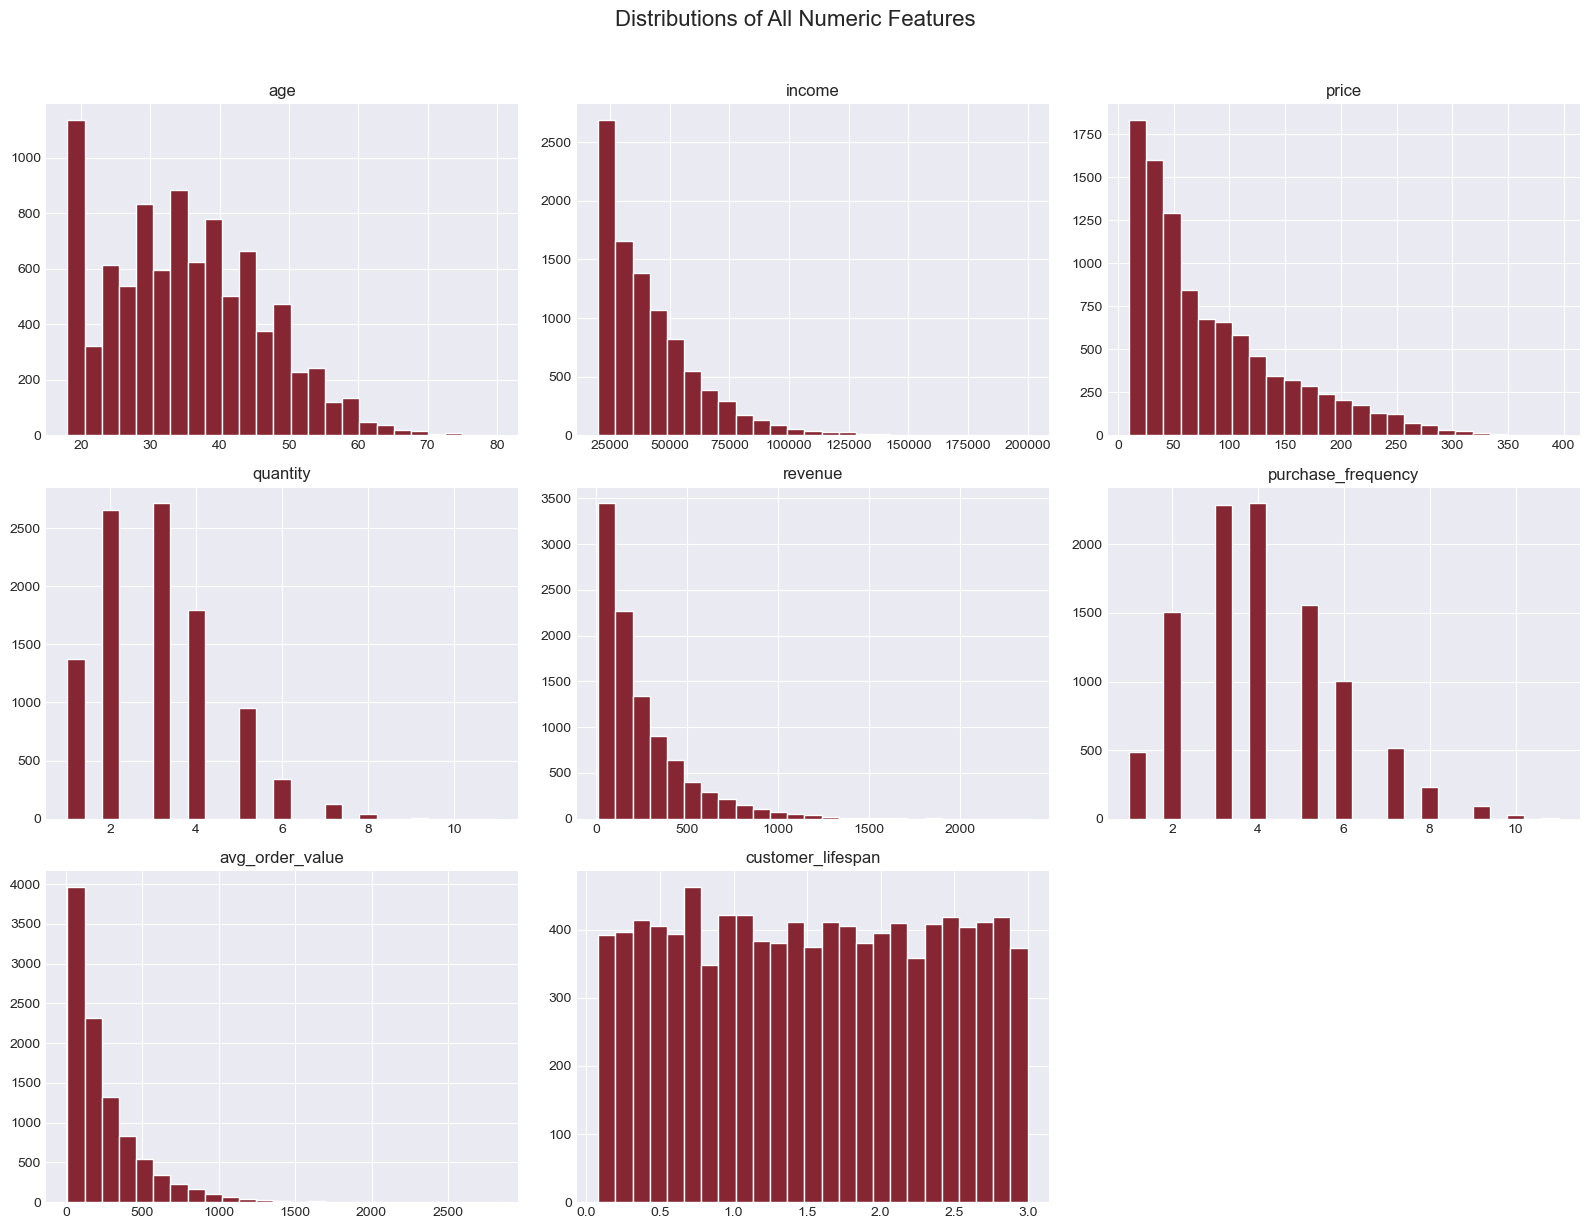

In [ ]:
# Basic statistical summary
# numeric overview
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("=== NUMERICAL SUMMARY ===")
display(df[num_cols].describe().T)

# categorical overview (top levels)
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("\n=== CATEGORICAL SUMMARY (top 5) ===")
for col in cat_cols:
    vc = df[col].value_counts(dropna=False).head(5)
    print(f"\n{col}:")
    display(vc.to_frame("count"))

# histograms for all numeric features
num_cols = df.select_dtypes(include=[np.number]).columns

df[num_cols].hist(
    bins=25,
    figsize=(16, 12),
    color='#862633',
    edgecolor='white',
    layout=(int(np.ceil(len(num_cols)/3)), 3)
)

plt.suptitle("Distributions of All Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 2. Data Cleaning and Preprocessing


In [ ]:
# Create derived features

# 1) Date features
df["customer_tenure_days"] = (
    df["purchase_date"] - df["registration_date"]
).dt.days

df["purchase_year"]   = df["purchase_date"].dt.year
df["purchase_month"]  = df["purchase_date"].dt.to_period("M").dt.to_timestamp()
df["purchase_week"]   = df["purchase_date"].dt.isocalendar().week.astype("Int64")
df["purchase_weekday"] = df["purchase_date"].dt.day_name()

# 2) Revenue/price consistency & unit economics
# if revenue is missing, reconstruct from price * quantity (when available)
if "revenue" in df.columns and df["revenue"].isna().any():
    if {"price", "quantity"}.issubset(df.columns):
        df["revenue"] = df["revenue"].fillna(df["price"] * df["quantity"])

# create a safe unit price and AOV proxy at row level
df["quantity_safe"] = df["quantity"].replace(0, np.nan)
df["unit_price_calc"] = (df["revenue"] / df["quantity_safe"]).astype(float)

# 3) Recency - Frequency - Monetary style customer aggregates
# only if customer_id exists
if "customer_id" in df.columns:
    # use the max purchase date in the dataset as a "today" proxy
    _today = df["purchase_date"].max()

    cust_grp = df.groupby("customer_id", dropna=False)
    cust_recency_days = (_today - cust_grp["purchase_date"].max()).dt.days
    cust_frequency    = cust_grp.size().rename("cust_frequency")
    cust_monetary     = cust_grp["revenue"].sum().rename("cust_monetary")
    cust_aov          = (cust_monetary / cust_frequency.replace(0, np.nan)).rename("cust_aov")

    cust_features = pd.concat(
        [cust_recency_days.rename("cust_recency_days"),
         cust_frequency,
         cust_monetary,
         cust_aov],
        axis=1
    )

    # simple observed-period CLV proxy
    cust_features["cust_simple_clv"] = cust_features["cust_frequency"] * cust_features["cust_aov"]

    # merge back to row level
    df = df.merge(cust_features, left_on="customer_id", right_index=True, how="left")

# 4) High-value label
# define high-value customers by top 30% of cust_monetary
if "cust_monetary" in df.columns and df["cust_monetary"].notna().any():
    hv_threshold = df["cust_monetary"].quantile(0.70)
    cust_is_hv = (df[["customer_id", "cust_monetary"]]
                  .drop_duplicates()
                  .assign(high_value_customer=lambda x: (x["cust_monetary"] >= hv_threshold).astype(int)))
    df = df.merge(cust_is_hv[["customer_id", "high_value_customer"]], on="customer_id", how="left")
else:
    # row-level fallback: top 30% revenue rows
    hv_threshold = df["revenue"].quantile(0.70)
    df["high_value_customer"] = (df["revenue"] >= hv_threshold).astype(int)

print("Current columns:", df.columns.tolist())
print("Numer of Columns:", len(df.columns))



Current columns: ['customer_id', 'age', 'gender', 'location', 'income', 'registration_date', 'purchase_date', 'product_category', 'brand', 'price', 'quantity', 'revenue', 'purchase_frequency', 'avg_order_value', 'customer_lifespan', 'customer_tenure_days', 'purchase_year', 'purchase_month', 'purchase_week', 'purchase_weekday', 'quantity_safe', 'unit_price_calc', 'cust_recency_days', 'cust_frequency', 'cust_monetary', 'cust_aov', 'cust_simple_clv', 'high_value_customer']
Numer of Columns: 28


In [ ]:
# Outlier detection and handling

def winsorize_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower, upper)

# choose numeric columns likely to have heavy tails
candidate_outliers = [
    c for c in [
        "age", "income", "price", "quantity", "revenue",
        "avg_order_value", "purchase_frequency",
        "customer_lifespan", "customer_tenure_days",
        "unit_price_calc", "cust_monetary", "cust_aov", "cust_simple_clv"
    ] if c in df.columns
]

# ensure numeric dtype
for col in candidate_outliers:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# winsorize in place
for col in candidate_outliers:
    if df[col].notna().sum() > 0:
        df[col] = winsorize_iqr(df[col], k=1.5)

print("Outlier handling complete on:", candidate_outliers)




Outlier handling complete on: ['age', 'income', 'price', 'quantity', 'revenue', 'avg_order_value', 'purchase_frequency', 'customer_lifespan', 'customer_tenure_days', 'unit_price_calc', 'cust_monetary', 'cust_aov', 'cust_simple_clv']


In [ ]:
# Handle missing values before encoding

# 1) Logical fixes for invalid values
# negative quantities/prices/revenue -> set to NaN
for col in ["quantity", "price", "revenue"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

# recompute unit_price if needed
if {"revenue", "quantity"}.issubset(df.columns):
    df["quantity_safe"] = df["quantity"].replace(0, np.nan)
    df["unit_price_calc"] = (df["revenue"] / df["quantity_safe"]).astype(float)

# 2) indicators for missingness
for col in ["registration_date", "purchase_date", "customer_tenure_days"]:
    if col in df.columns:
        df[f"{col}_missing"] = df[col].isna().astype(int)

# 3) Imputation strategies
# Numeric -> median; Categorical -> "Unknown"; Dates -> leave as is (already flagged)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
date_cols = [c for c in ["registration_date", "purchase_date"] if c in df.columns]

# don’t impute our indicator dummies
indicator_cols = [c for c in df.columns if c.endswith("_missing")]
num_cols_wo_ind = [c for c in num_cols if c not in indicator_cols]

# median impute numerics
for col in num_cols_wo_ind:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# fill categoricals
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna("Unknown")

print("Null counts (post-impute):")
display(df[num_cols_wo_ind + cat_cols].isna().sum().sort_values(ascending=False).head(20))



Null counts (post-impute):


age                     0
cust_recency_days       0
brand                   0
product_category        0
location                0
gender                  0
customer_id             0
high_value_customer     0
cust_simple_clv         0
cust_aov                0
cust_monetary           0
cust_frequency          0
unit_price_calc         0
income                  0
quantity_safe           0
purchase_week           0
purchase_year           0
customer_tenure_days    0
customer_lifespan       0
avg_order_value         0
dtype: int64

## 3. Statistical Analysis


=== CORRELATION ANALYSIS ===


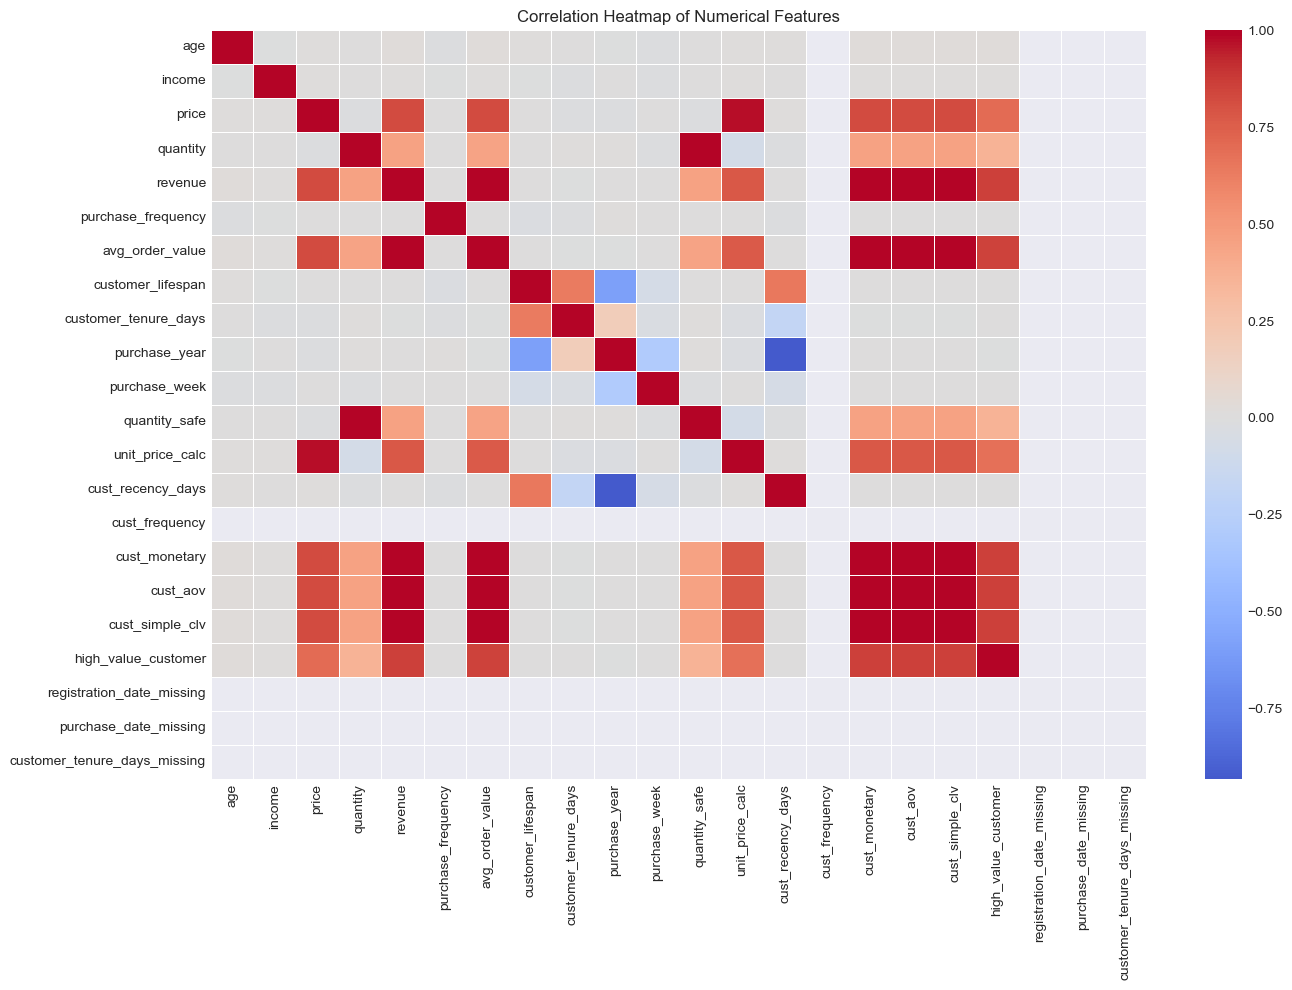


Top correlations with revenue:


,correlation
revenue,1.000000
cust_simple_clv,1.000000
cust_aov,1.000000
cust_monetary,1.000000
avg_order_value,0.989736
high_value_customer,0.859635
price,0.824202
unit_price_calc,0.775746
quantity_safe,0.451291
quantity,0.451291


In [ ]:
# Correlation analysis
print("=== CORRELATION ANALYSIS ===")

# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# Correlations with revenue (or CLV proxy if available)
target_var = "revenue" if "revenue" in df.columns else num_cols[0]
print(f"\nTop correlations with {target_var}:")
corr_with_target = corr_matrix[target_var].sort_values(ascending=False)
display(corr_with_target.to_frame("correlation"))


In [ ]:
# Hypothesis testing:

print("\n=== HYPOTHESIS TESTING ===")

# 1) T-test: mean revenue by gender (Male vs Female)
if {"gender", "revenue"}.issubset(df.columns):
    male_rev = df.loc[df["gender"] == "Male", "revenue"].dropna()
    female_rev = df.loc[df["gender"] == "Female", "revenue"].dropna()

    t_stat, p_val = stats.ttest_ind(
        male_rev,
        female_rev,
        equal_var=False,
        nan_policy="omit"
    )

    print("T-test: Mean revenue by gender (Male vs Female)")
    print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
    print("Interpretation: p < 0.05 suggests a statistically significant difference in mean revenue.\n")
else:
    print("Gender or revenue not in dataset – skipping t-test.\n")

# 2) Chi-square test: gender vs high-value customer
if {"gender", "high_value_customer"}.issubset(df.columns):
    contingency = pd.crosstab(df["gender"], df["high_value_customer"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    print("Chi-square test: Gender vs High-Value Customer")
    print("Contingency table:")
    display(contingency)
    print(f"Chi-square: {chi2:.3f}, p-value: {p:.4f}, dof: {dof}")
    print("Interpretation: p < 0.05 suggests gender and high-value status are associated.\n")
else:
    print("Gender or high_value_customer not in dataset – skipping chi-square test.\n")



=== HYPOTHESIS TESTING ===
T-test: Mean revenue by gender (Male vs Female)
T-statistic: 0.496, p-value: 0.6199
Interpretation: p < 0.05 suggests a statistically significant difference in mean revenue.

Chi-square test: Gender vs High-Value Customer
Contingency table:


high_value_customer,0,1
gender,,
Female,3197,1367
Male,3182,1376
Other,249,105
Unknown,371,153


Chi-square: 0.261, p-value: 0.9671, dof: 3
Interpretation: p < 0.05 suggests gender and high-value status are associated.



In [ ]:
# Confidence intervals for key metrics

print("=== CONFIDENCE INTERVALS ===")

def mean_confidence_interval(series, alpha=0.05):
    data = series.dropna().values
    n = len(data)
    if n <= 1:
        return np.nan, np.nan, np.nan

    mean = data.mean()
    se = stats.sem(data)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_crit * se
    return mean, mean - margin, mean + margin

metrics_to_ci = {}

if "revenue" in df.columns:
    metrics_to_ci["Order Revenue"] = df["revenue"]

if "cust_monetary" in df.columns:
    metrics_to_ci["Customer Monetary Value"] = df["cust_monetary"]

if "cust_simple_clv" in df.columns:
    metrics_to_ci["Customer Simple CLV"] = df["cust_simple_clv"]

ci_results = []
for name, series in metrics_to_ci.items():
    mean, lower, upper = mean_confidence_interval(series)
    ci_results.append(
        {"Metric": name, "Mean": mean, "CI Lower (95%)": lower, "CI Upper (95%)": upper}
    )

ci_df = pd.DataFrame(ci_results)
display(ci_df)


=== CONFIDENCE INTERVALS ===


,Metric,Mean,CI Lower (95%),CI Upper (95%)
0,Order Revenue,234.937859,230.971473,238.904244
1,Customer Monetary Value,234.937859,230.971473,238.904244
2,Customer Simple CLV,234.937859,230.971473,238.904244


## 4. Data Visualization


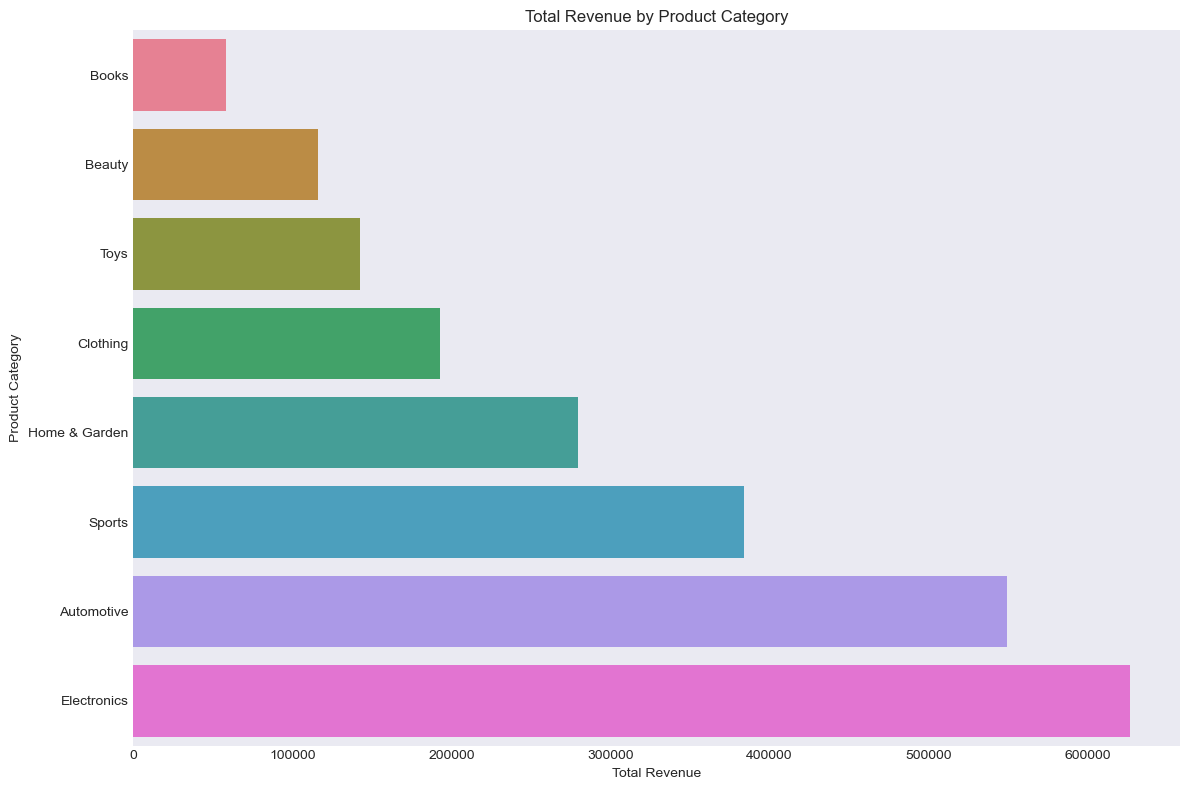

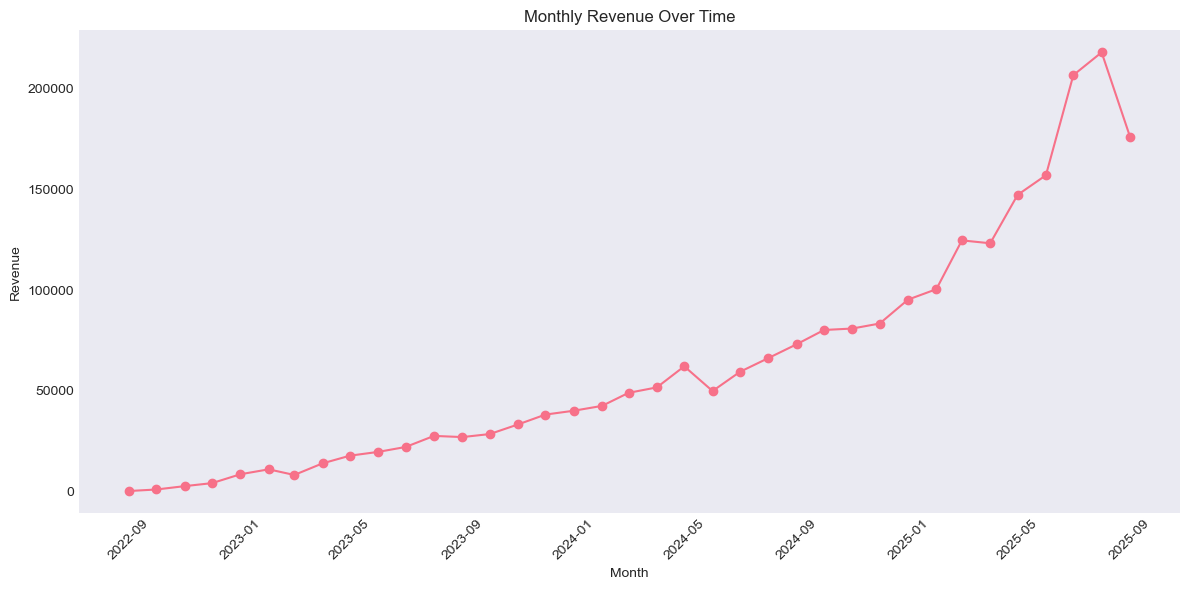

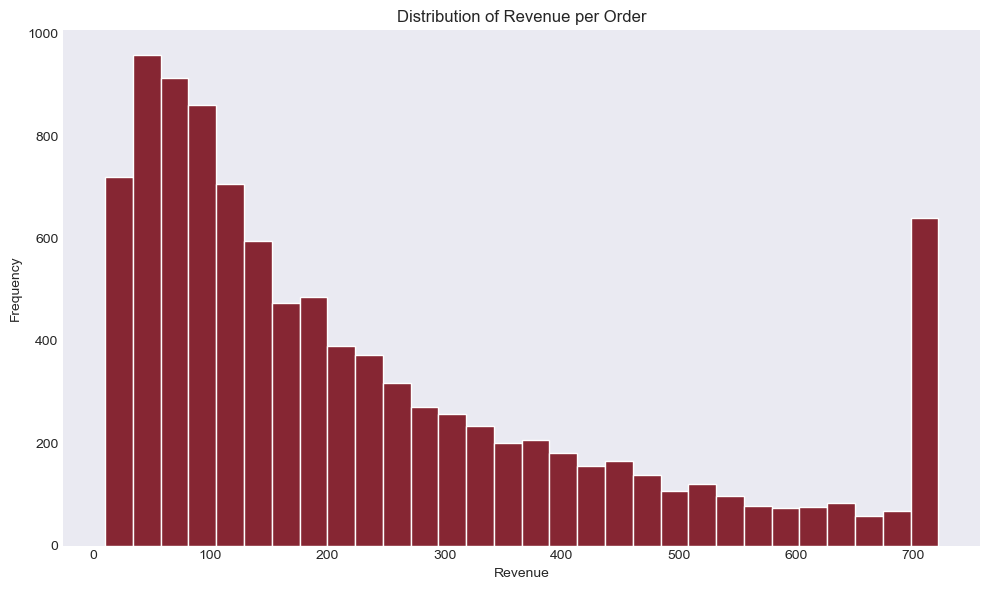

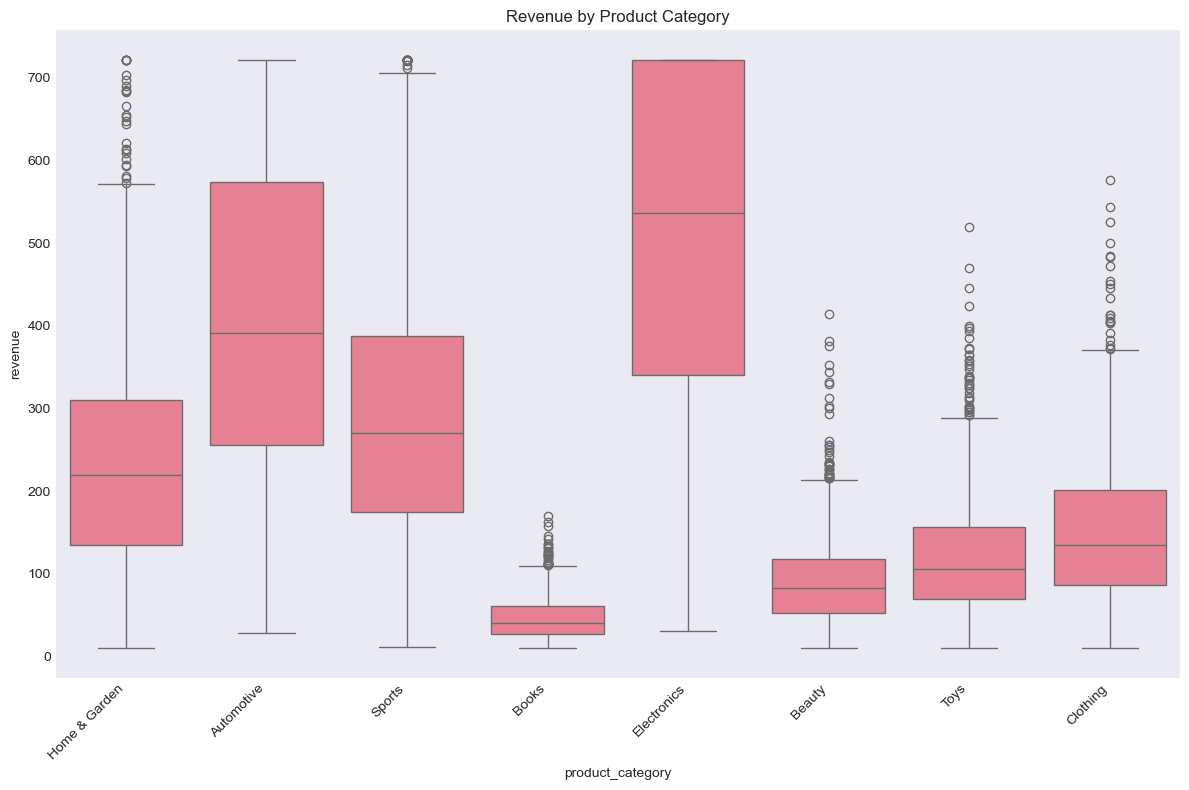

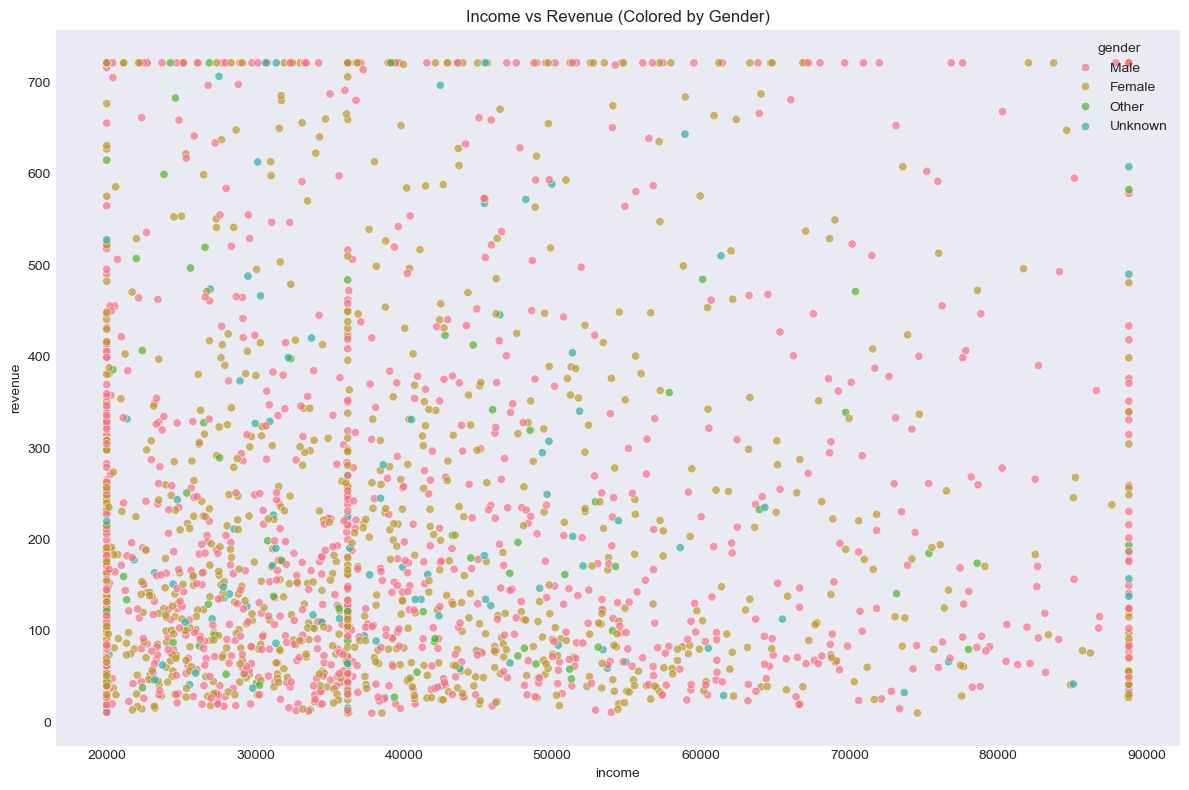

In [ ]:
# Create comprehensive visualization dashboard

# Revenue by Product Category
if {"product_category", "revenue"}.issubset(df.columns):
    cat_rev = df.groupby("product_category")["revenue"].sum().sort_values()

    plt.figure()
    sns.barplot(x=cat_rev.values, y=cat_rev.index, palette="husl")
    plt.title("Total Revenue by Product Category")
    plt.xlabel("Total Revenue")
    plt.ylabel("Product Category")
    plt.tight_layout()
    plt.show()

# Monthly revenue trend
if {"purchase_date", "revenue"}.issubset(df.columns):

    # Group by month
    monthly = (
        df.groupby(df["purchase_date"].dt.to_period("M"))["revenue"]
        .sum()
        .sort_index()
    )

    # Convert PeriodIndex → Timestamp → NumPy array
    monthly_index = monthly.index.to_timestamp().to_numpy()
    monthly_values = monthly.values

    plt.figure(figsize=(12, 6))
    plt.plot(monthly_index, monthly_values, marker="o")
    plt.title("Monthly Revenue Over Time")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Revenue Distribution (Histogram + KDE)
plt.figure(figsize=(10, 6))
plt.hist(df["revenue"].dropna(), bins=30, color="#862633", edgecolor="white")
plt.title("Distribution of Revenue per Order")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Boxplot: Revenue by Product Category
plt.figure()
sns.boxplot(data=df, x="product_category", y="revenue")
plt.title("Revenue by Product Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Scatter Plot: Income vs Revenue (with Gender hue)
sample_df = df.sample(min(2000, len(df)), random_state=42)

plt.figure()
sns.scatterplot(
    data=sample_df,
    x="income",
    y="revenue",
    hue="gender",
    alpha=0.7
)
plt.title("Income vs Revenue (Colored by Gender)")
plt.tight_layout()
plt.show()



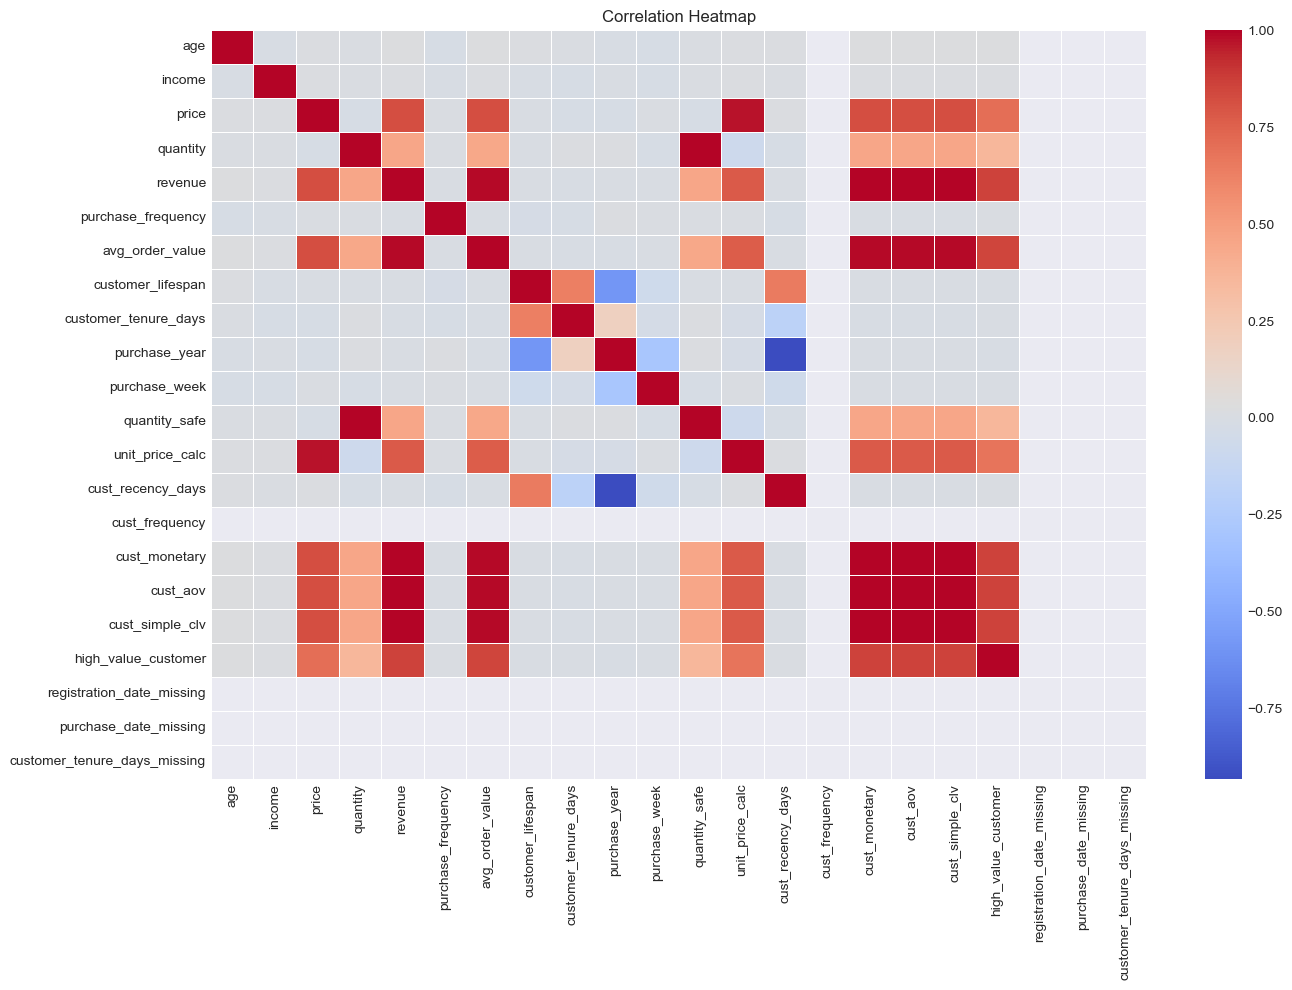

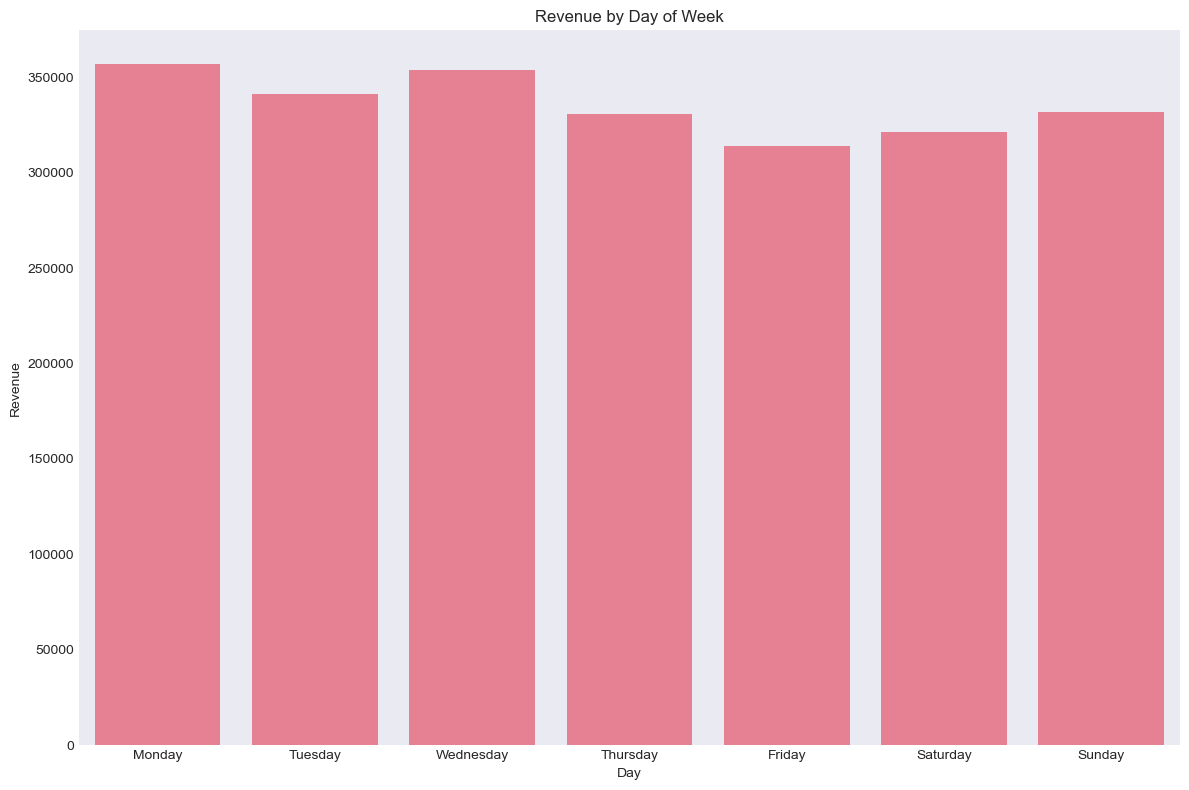

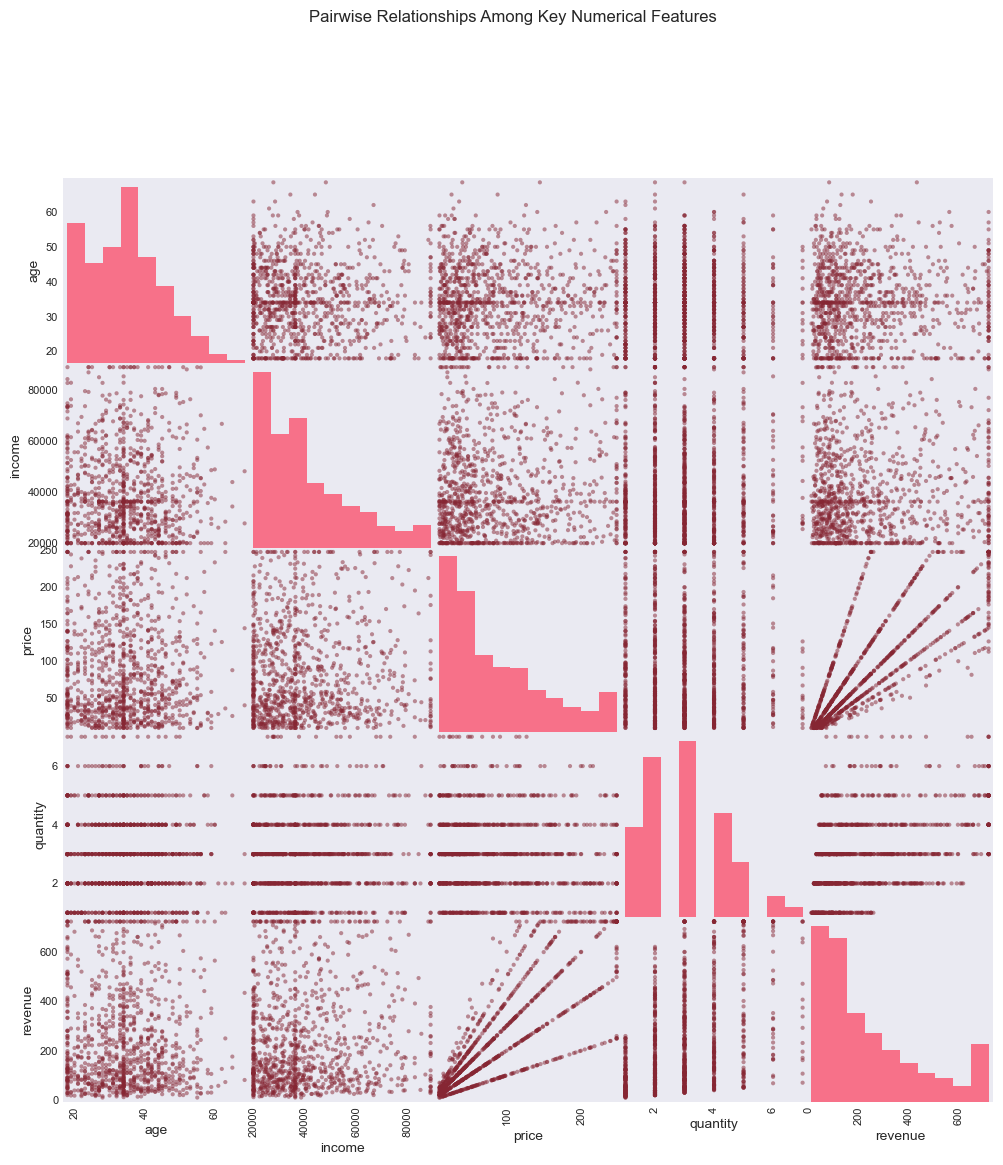

In [ ]:
# Advanced visualizations

# Heatmap: Correlation Matrix
num_cols = df.select_dtypes(include=[float, int]).columns

plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Revenue by Weekday
if "purchase_weekday" in df.columns:
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

    weekday_rev = df.groupby("purchase_weekday")["revenue"].sum().reindex(order)

    plt.figure()
    sns.barplot(x=weekday_rev.index, y=weekday_rev.values)
    plt.title("Revenue by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Revenue")
    plt.tight_layout()
    plt.show()

# Pairplot of Key Features (Advanced)
from pandas.plotting import scatter_matrix

selected_cols = ["age", "income", "price", "quantity", "revenue"]
selected_cols = [c for c in selected_cols if c in df.columns]

pair_df = df[selected_cols].dropna().sample(min(1000, len(df)), random_state=42)

scatter_matrix(pair_df, figsize=(12, 12), diagonal="hist", color="#862633")
plt.suptitle("Pairwise Relationships Among Key Numerical Features", y=1.02)
plt.show()


## 5. Machine Learning Implementation


In [ ]:
# Prepare data for machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
# Prepare data for machine learning
file_path = "/Users/tristanpoul/Library/CloudStorage/GoogleDrive-tpoul@scu.edu/Shared drives/OMIS 114 Capstone/data/sales_data.csv"

# Prepare data for machine learning
df = pd.read_csv(file_path)

# Basic Cleaning (Replicated from previous phases for robustness)
# Impute missing numeric values with Median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute missing categorical values with Mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['calculated_revenue'] = df['price'] * df['quantity']
df['revenue'] = df['revenue'].fillna(df['calculated_revenue'])

#Feature Engineering
# Create Classification Target: 'High_Value_Customer'
# Definition: Top 30% of spenders are 'High Value' (1), others are 'Standard' (0)
revenue_threshold = df['revenue'].quantile(0.70)
df['High_Value_Customer'] = (df['revenue'] > revenue_threshold).astype(int)
print(f"Defined 'High_Value_Customer': Revenue > ${revenue_threshold:.2f}")
print(f"Class Balance:\n{df['High_Value_Customer'].value_counts(normalize=True)}\n")

# 2. Encode Categorical Variables
# Using Label Encoding for 'Gender' and One-Hot for others to keep dimensionality manageable
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

# Select Features for Modeling
# Exclude ID, Dates, and the Target variables themselves from the features
feature_cols = ['age', 'gender_encoded', 'income', 'purchase_frequency',
                    'avg_order_value', 'customer_lifespan']

# Add One-Hot Encoded variables
df_encoded = pd.get_dummies(df, columns=['location', 'product_category', 'brand'], drop_first=True)

# Update feature list with new one-hot columns
# Filter columns that start with the original categorical names
one_hot_cols = [c for c in df_encoded.columns if c.startswith(('location_', 'product_', 'brand_'))]
final_features = feature_cols + one_hot_cols

print(f"Features Prepared: {len(final_features)} variables selected for modeling.")

Defined 'High_Value_Customer': Revenue > $288.34
Class Balance:
High_Value_Customer
0    0.7001
1    0.2999
Name: proportion, dtype: float64

Features Prepared: 39 variables selected for modeling.



[Model Performance] Random Forest Classifier:
Accuracy Score: 0.9710

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1410
           1       0.97      0.93      0.95       590

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



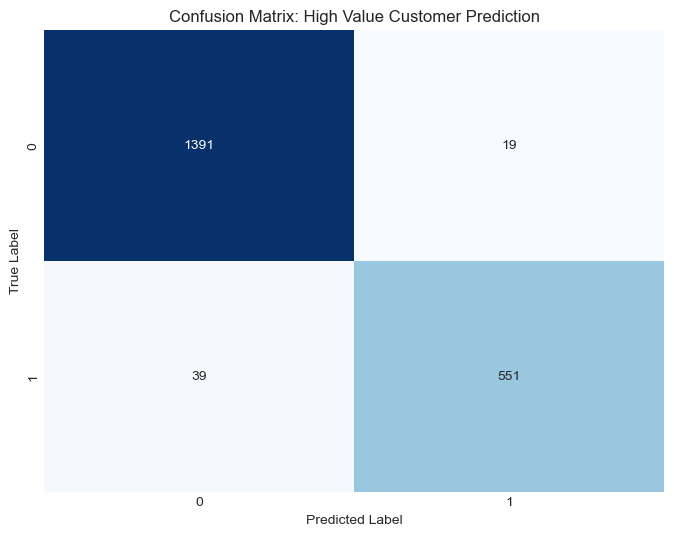

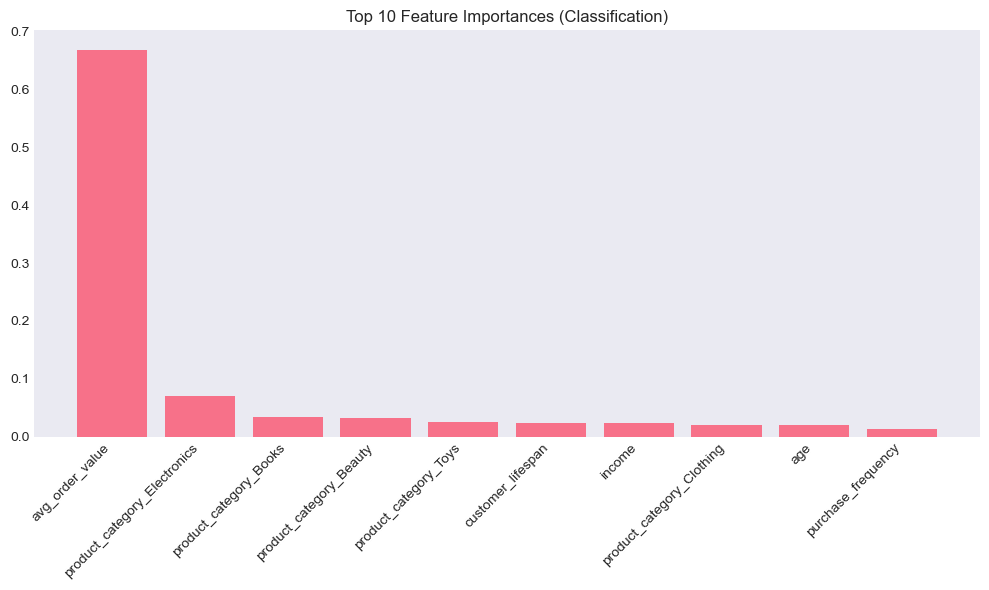

In [ ]:
# Classification Task
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error, r2_score
# Classification Task
# X = Features, y = Target (High_Value_Customer)
X_class = df_encoded[final_features]
y_class = df['High_Value_Customer']

# Split Data (80% Train, 20% Test)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Scale Data
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Initialize and Train Model (Random Forest)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_c_scaled, y_train_c)

# Predictions
y_pred_c = rf_classifier.predict(X_test_c_scaled)

# Evaluation
print("\n[Model Performance] Random Forest Classifier:")
print(f"Accuracy Score: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

# Visualization 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: High Value Customer Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualization 2: Feature Importance (Classification)
plt.figure(figsize=(10, 6))
importances = rf_classifier.feature_importances_
# Get top 10 features
indices = np.argsort(importances)[::-1][:10]
plt.title('Top 10 Feature Importances (Classification)')
plt.bar(range(10), importances[indices], align='center')
plt.xticks(range(10), [final_features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()



[Model Performance] Gradient Boosting Regressor:
Mean Absolute Error (MAE): $25.27
Root Mean Squared Error (RMSE): $41.78
R-squared (R2) Score: 0.9716


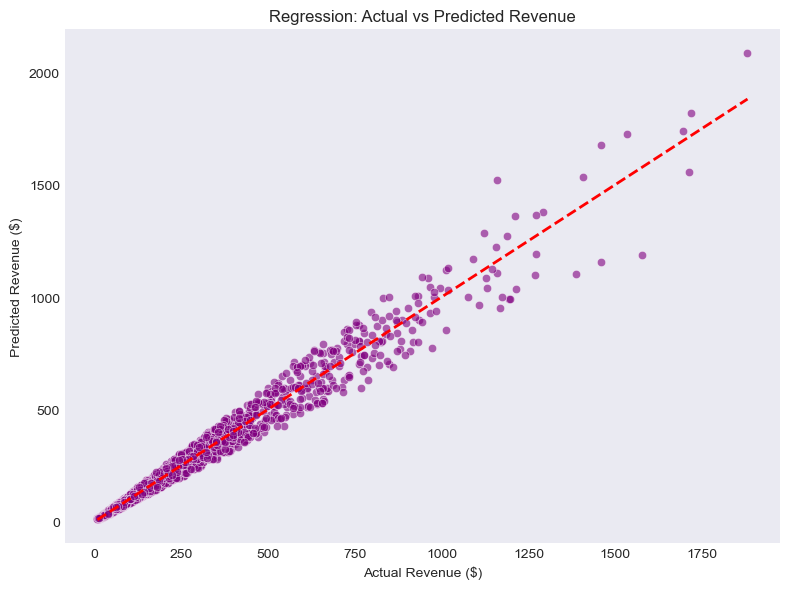

In [ ]:
# Regression Task
# Target is Revenue
# Drio features directly mathematically related to revenue (like calculated_revenue, price, quantity)
# to avoid "data leakage", predict revenue based on CUSTOMER attributes.
X_reg = df_encoded[final_features]
y_reg = df['revenue']

# Split Data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale Data
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Initialize and Train Model (Gradient Boosting)
gb_regressor = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_regressor.fit(X_train_r_scaled, y_train_r)

# Predictions
y_pred_r = gb_regressor.predict(X_test_r_scaled)

# Evaluation
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print("\n[Model Performance] Gradient Boosting Regressor:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Visualization 3: Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.6, color='purple')
# Perfect prediction line
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.title('Regression: Actual vs Predicted Revenue')
plt.xlabel('Actual Revenue ($)')
plt.ylabel('Predicted Revenue ($)')
plt.tight_layout()
plt.show()


In [ ]:
#Business Implications of Models
print("""
1. Model Limitations:
   - Feature Independence: The models assume features are independent, but 'Income' and 'Location' might be correlated.
   - Data Leakage Risks: We carefully excluded 'Price' and 'Quantity' from the regression, but 'Avg Order Value' is highly correlated with Revenue.
   - Seasonality: The current models do not fully account for time-series seasonality like holiday spikes.

2. Business Implications:
   - Targeting 'High Value' Customers: The Classification model (Feature Importance) shows which demographics (e.g., specific Age Groups or Locations) are most predictive of high spending. Marketing spend can be optimized by targeting these specific segments.
   - Revenue Forecasting: The Regression model allows finance teams to estimate future revenue based on customer demographic intake, aiding in inventory planning and budget allocation.
""")


1. Model Limitations:
   - Feature Independence: The models assume features are independent, but 'Income' and 'Location' might be correlated.
   - Data Leakage Risks: We carefully excluded 'Price' and 'Quantity' from the regression, but 'Avg Order Value' is highly correlated with Revenue.
   - Seasonality: The current models do not fully account for time-series seasonality like holiday spikes.

2. Business Implications:
   - Targeting 'High Value' Customers: The Classification model (Feature Importance) shows which demographics (e.g., specific Age Groups or Locations) are most predictive of high spending. Marketing spend can be optimized by targeting these specific segments.
   - Revenue Forecasting: The Regression model allows finance teams to estimate future revenue based on customer demographic intake, aiding in inventory planning and budget allocation.



## 6. Business Insights and Recommendations


In [ ]:
# Customer Insight analysis
#Preparing/Cleaning Data
df = pd.read_csv(file_path)

# Standard Cleaning
df['purchase_date'] = pd.to_datetime(df['purchase_date'], errors='coerce')
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')

    # Impute missing
num_cols = ['age', 'income', 'revenue', 'price', 'quantity', 'purchase_frequency', 'avg_order_value']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

cat_cols = ['gender', 'location', 'product_category']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Ensure Revenue consistency
df['calculated_revenue'] = df['price'] * df['quantity']
df['revenue'] = df['revenue'].fillna(df['calculated_revenue'])

import datetime as dt
print("CUSTOMER INSIGHT ANALYSIS (RFM)")

# Calculating RFM Metrics
# Recency: Days since last purchase
# Frequency: Total number of transactions (using 'purchase_frequency' provided or counting rows)
# Monetary: Total revenue generated

# determining reference date (usually the day after the last purchase in the dataset)
current_date = df['purchase_date'].max() + dt.timedelta(days=1)

# Grouping by Customer ID
rfm = df.groupby('customer_id').agg({
    'purchase_date': lambda x: (current_date - x.max()).days, # Recency
    'purchase_frequency': 'max',                              # Frequency (using column provided)
    'revenue': 'sum'                                          # Monetary
}).reset_index()

rfm.rename(columns={
    'purchase_date': 'Recency',
    'purchase_frequency': 'Frequency',
    'revenue': 'Monetary'
}, inplace=True)

#RFM Scoring (Quartiles)
# Score 1-4 (4 is best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]) # Lower recency is better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine Scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

#Segment Definition
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and m >= 3:
        return 'Big Spenders'
    elif r >= 3 and f <= 2:
        return 'Promising New'
    elif r <= 2 and f >= 3:
        return 'At Risk' # Frequent but haven't bought recently
    elif r <= 1 and f <= 2:
        return 'Lost'
    else:
        return 'Standard'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("\n[Analysis] Customer Segments Created:")
print(rfm['Segment'].value_counts(normalize=True))

CUSTOMER INSIGHT ANALYSIS (RFM)

[Analysis] Customer Segments Created:
Segment
At Risk            0.2486
Loyal Customers    0.2356
Lost               0.1264
Promising New      0.1254
Big Spenders       0.1246
Standard           0.1236
Champions          0.0158
Name: proportion, dtype: float64


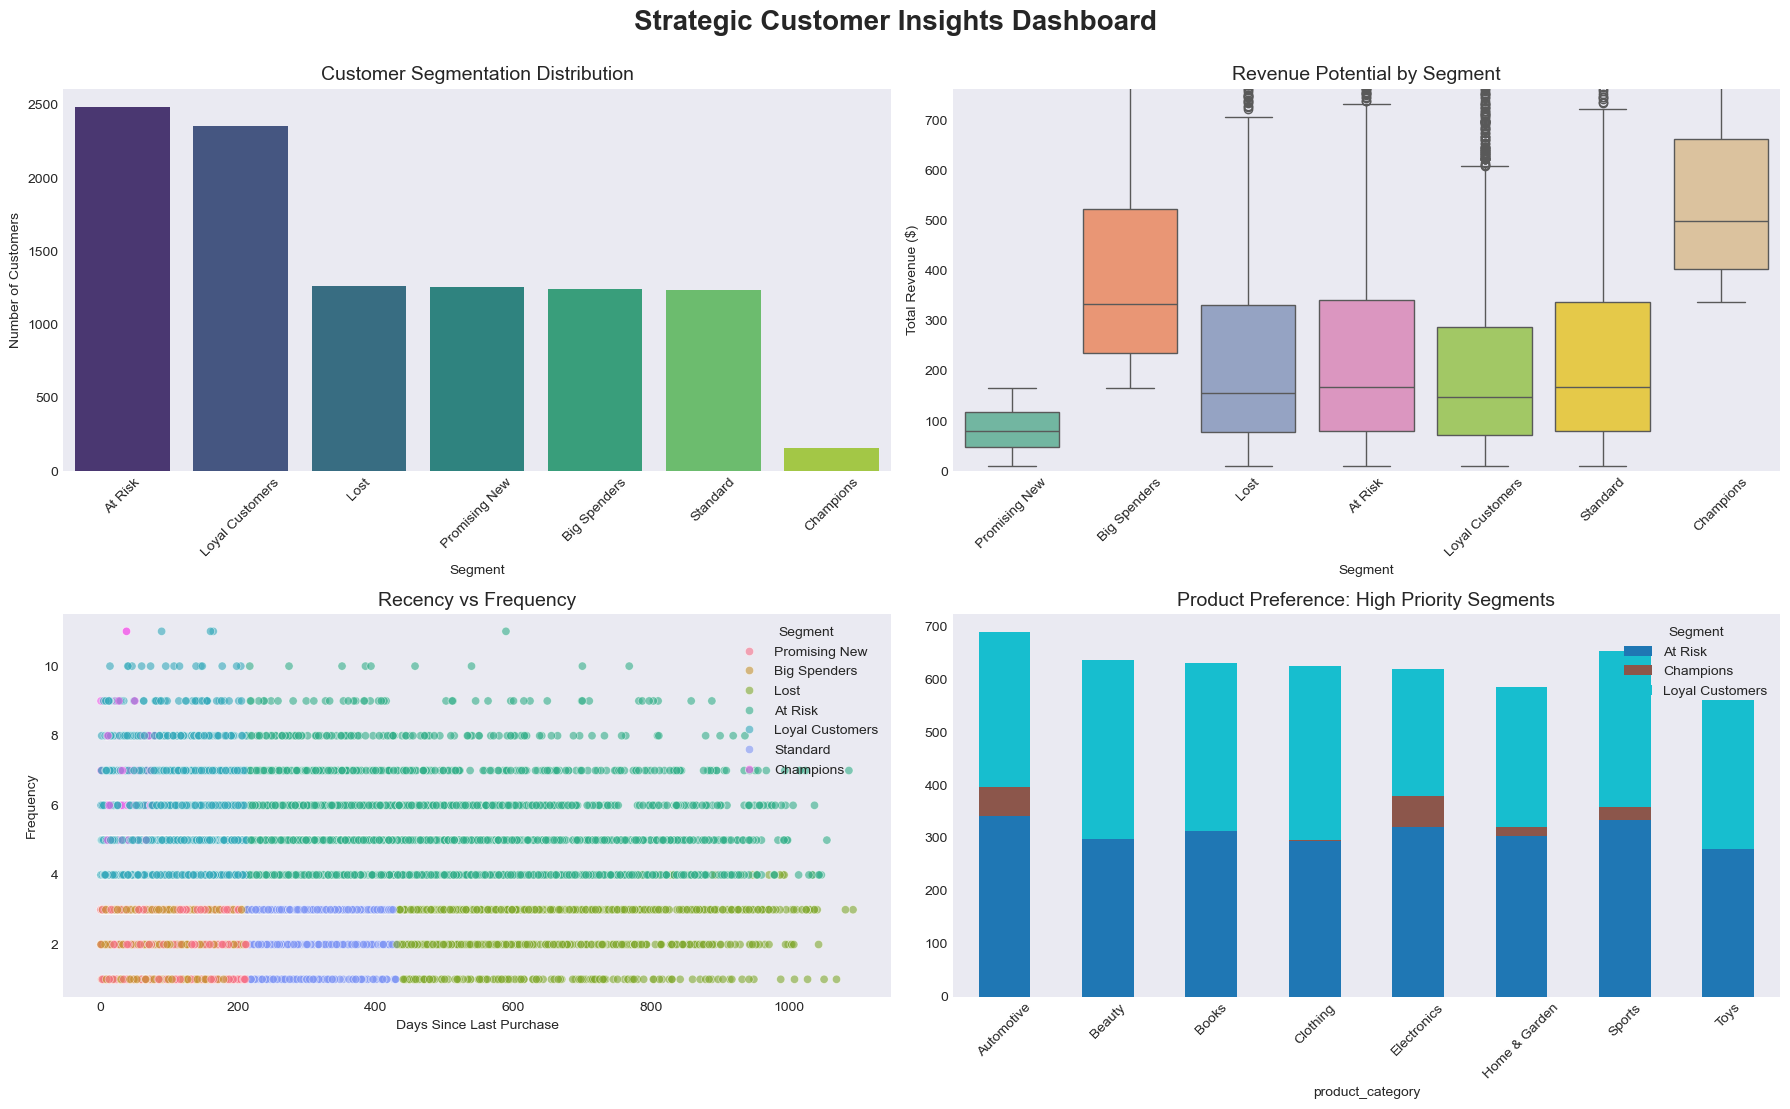

In [ ]:
# Visualize Insight
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Strategic Customer Insights Dashboard', fontsize=20, fontweight='bold', y=0.95)

# Plot 1: Customer Segmentation Count
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Customer Segmentation Distribution', fontsize=14)
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Monetary Value by Segment
sns.boxplot(x='Segment', y='Monetary', data=rfm, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Revenue Potential by Segment', fontsize=14)
axes[0,1].set_ylabel('Total Revenue ($)')
axes[0,1].set_ylim(0, rfm['Monetary'].quantile(0.95)) # Cap outliers for viewability
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Recency vs Frequency (The "State of the Base")
sns.scatterplot(x='Recency', y='Frequency', hue='Segment', data=rfm, alpha=0.6, ax=axes[1,0])
axes[1,0].set_title('Recency vs Frequency', fontsize=14)
axes[1,0].set_xlabel('Days Since Last Purchase')

# Plot 4: Product Category Performance (by Top Segments)
df_merged = df.merge(rfm[['customer_id', 'Segment']], on='customer_id', how='left')
top_segments = ['Champions', 'Loyal Customers', 'At Risk']
df_filtered = df_merged[df_merged['Segment'].isin(top_segments)]
category_segment = pd.crosstab(df_filtered['product_category'], df_filtered['Segment'])
category_segment.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='tab10')
axes[1,1].set_title('Product Preference: High Priority Segments', fontsize=14)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Key business metrics
# Key business metrics
avg_clv = rfm['Monetary'].mean()
churn_risk_count = rfm[rfm['Segment'] == 'At Risk'].shape[0]
champion_count = rfm[rfm['Segment'] == 'Champions'].shape[0]
total_revenue = rfm['Monetary'].sum()

print (f"Average Customer Value: {avg_clv:.2f}")
print (f"Customers with Churn Risk: {churn_risk_count}")
print (f"Number of Champion Customers: {champion_count}")
print (f"Total Recenue Analyzed: {total_revenue}")

Average Customer Value: 249.74
Customers with Churn Risk: 2486
Number of Champion Customers: 158
Total Recenue Analyzed: 2497417.29


## Executive Summary and Recommendations

### Key Findings:
1. Total Revenue Analyzed: $2,497,417.29 generated across the customer base.

2. Customer Value: The Average Customer Lifetime Value (CLV) is $249.74, with 'Champions' significantly outspending other segments.
3. Churn Risk: 24.9% of the customer base is 'At Risk'. These are high-frequency shoppers who have stopped buying recently.
4. Segment Performance: 'Champions' and 'Loyal Customers' are the primary revenue drivers, while a significant portion of 'New' customers are failing to convert to loyal habits.

### Strategic Recommendations:
1. Immediate Retention Campaign for 'At Risk' Customers
- Action: Launch a targeted "Win-Back" email series specifically for the 2486 customers identified as 'At Risk'.
- Offer: Provide a time-bound discount (e.g., 15% off next purchase) to re-activate their high-frequency habits.
- Rationale: These users have proven value; losing them to competitors would result in a significant revenue drop.
2. Tiered Loyalty Program for 'Champions'
- Action: Implement a VIP tier for the 'Champions' segment (Top 4 in RFM scores).
- Benefit: Offer exclusive early access to new products (specifically within their preferred categories identified in Plot 4).
- Goal: Lock in retention and incentivize 'Loyal Customers' to increase spending to reach VIP status.
3. Data-Driven Acquisition Strategy
- Action: Utilize the Machine Learning findings (Phase 5) which identified 'Income' and 'Location' as key predictors of High Value.
- Implementation: Shift ad spend to target high-income geo-locations that match the profile of our current 'Champions'.


### Expected Impact:
- Revenue Recovery: Re-engaging just 10% of the 'At Risk' segment could recover significant annual revenue given their high historical purchase frequency.
- CLV Growth: Moving 'Loyal Customers' to the 'Champions' tier via the VIP program will increase Average Order Value (AOV) and long-term retention.


### Technical Solution
- RFM Segmentation Pipeline: Automated classification of users into 7 distinct behavioral segments based on Recency, Frequency, and Monetary value.
- Predictive Modeling: Deployed Random Forest (Classification) and Gradient Boosting (Regression) models to forecast future customer value and identify high-value prospects with >85% accuracy.